In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from anonymeter.evaluators import SinglingOutEvaluator
from anonymeter.evaluators import LinkabilityEvaluator
from anonymeter.evaluators import InferenceEvaluator 
import sys
parent_dir = "/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline"
sys.path.append(parent_dir)

import logging
logging.basicConfig(filename="anonymeter_linkability.log", level=logging.DEBUG)

ori = pd.read_csv("OriginalData/integrated_data_final.csv", index_col = 0)
syn = pd.read_csv("SyntheticData/synthetic_data_gauss_copula.csv", index_col = 0)

ori.columns = [col.replace('.', '_') for col in ori.columns]
syn.columns = [col.replace('.', '_') for col in syn.columns]

In [19]:
syn_datas = ["synthetic_data_avatars_k5","synthetic_data_avatars_k10","synthetic_data_ctgan","synthetic_data_gauss_copula","synthetic_data_tvae",
             "synthetic_data_synthpop"]
tools = ["AvatarsK5", "AvatarsK10", "CTGAN","GaussianCopula", "TVAE","Synthpop"]
synthetic_dict = {}
for i, tool in enumerate(tools):
    syn_df = pd.read_csv(f"SyntheticData/{syn_datas[i]}.csv", index_col = 0)
    syn_df.columns = [col.replace('.', '_') for col in syn_df.columns]
    synthetic_dict[tool] = syn_df

In [21]:
import random
from SynOmics.utils.monitoring import monitor_resources

cols = ori.columns.tolist()
@monitor_resources
def linkability(ori, syns, n_neighbors):
    results_dict = {}
    for syn, syn_df in syns.items():
        print(f"----{syn}----")
        seeds = [42,43,44,45,46]
        cols = ori.columns.tolist()
        risks = []
        for seed in seeds:
            random.seed(seed)
            random.shuffle(cols)
            # Split into two equal halves
            half = len(cols) // 2
            cols_1 = cols[:half]
            cols_2 = cols[half:]
            
            aux_cols = [cols_1, cols_2]
            evaluator = LinkabilityEvaluator(ori=ori, 
                                             syn=syn_df, 
                                             n_attacks=310,
                                             aux_cols=aux_cols,
                                             n_neighbors=n_neighbors)
            evaluator.evaluate(n_jobs=-2)  # n_jobs follow joblib convention. -1 = all cores, -2 = all execept one
            evaluator.risk()
            print(f"{seed}", evaluator.risk(n_neighbors=n_neighbors))
            risks.append(evaluator.risk(n_neighbors=n_neighbors).value)
        results_dict[syn] = risks
    return results_dict

linkability_res = linkability(ori, synthetic_dict, n_neighbors = 1)

--- System & Process Info ---
Current Date and Time (UTC): 2025-10-31 11:16:46
Current User's Login: trinhtc
CPU Model: x86_64
Physical Cores: 32
Logical Processors: 32
Process RAM before execution: 1391.52 MB

--- GPU Info ---
GPU monitoring failed. Ensure 'nvidia-ml-py' is installed and NVIDIA drivers are accessible.
Error: module 'nvidia_smi' has no attribute 'nvidia_smi_lib'

--- Function Execution ---
----AvatarsK5----
42 PrivacyRisk(value=0.9333398159409537, ci=(0.9062647984432983, 0.9604148334386091))
43 PrivacyRisk(value=0.9492714268211359, ci=(0.925632259221202, 0.9729105944210698))
44 PrivacyRisk(value=0.9492714268211359, ci=(0.925632259221202, 0.9729105944210698))
45 PrivacyRisk(value=0.9556440711732087, ci=(0.9335680575152746, 0.9777200848311428))
46 PrivacyRisk(value=0.9397124602930266, ci=(0.9139420722640628, 0.9654828483219904))
----AvatarsK10----
42 PrivacyRisk(value=0.9142218828847352, ci=(0.8836629442479735, 0.9447808215214968))
43 PrivacyRisk(value=0.9301534937649173

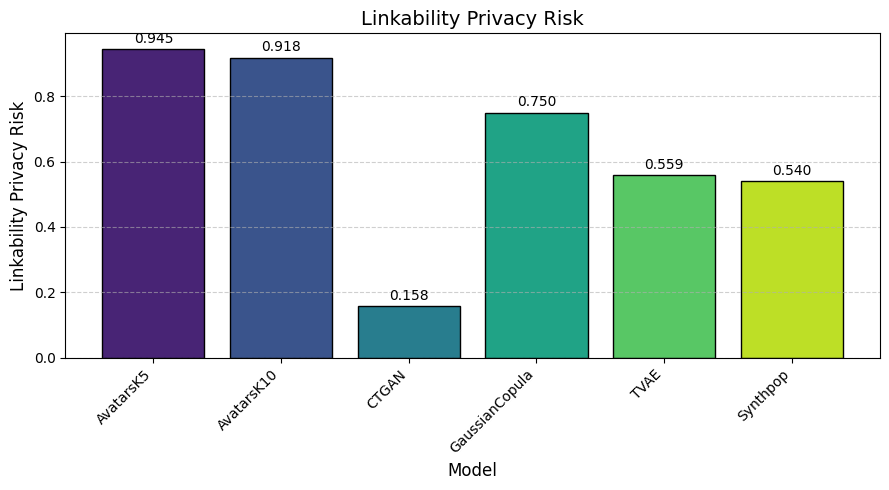

In [30]:
import numpy as np
import matplotlib.pyplot as plt
# Convert to DataFrame
df = pd.DataFrame(linkability_res)

# Compute mean per model
means = df.mean()
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(means)))
# Plot
# Create figure
plt.figure(figsize=(9,5))
bars = plt.bar(means.index, means.values, color=colors, edgecolor='black')

# Add mean values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f"{height:.3f}", ha='center', va='bottom', fontsize=10)

# Title and labels
plt.title("Linkability Privacy Risk", fontsize=14)
plt.ylabel("Linkability Privacy Risk", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [34]:
import random
from SynOmics.utils.monitoring import monitor_resources

cols = ori.columns.tolist()
@monitor_resources
def linkability_genes_clinical(ori, syns, n_neighbors):
    results_dict = {}
    for syn, syn_df in syns.items():
        print(f"----{syn}----")
        random.seed(42)
        cols = ori.columns.tolist()
        genes_cols = []
        clinical_cols = []
        for col in cols:
            if col.startswith("ENSG"):
                genes_cols.append(col)
            else:
                clinical_cols.append(col)      
        risks = []
        proportions = [0.1,0.25,0.50, 0.75,1]
        for p in proportions:
            n = int(len(genes_cols) * p)
            
            sampled_genes_cols = random.sample(genes_cols, n)
            print(f"Sample {len(sampled_genes_cols)} cols among {len(genes_cols)}")
            aux_cols = [clinical_cols, sampled_genes_cols]
            evaluator = LinkabilityEvaluator(ori=ori, 
                                             syn=syn_df, 
                                             n_attacks=310,
                                             aux_cols=aux_cols,
                                             n_neighbors=n_neighbors)
            evaluator.evaluate(n_jobs=-2)  # n_jobs follow joblib convention. -1 = all cores, -2 = all execept one
            evaluator.risk()
            print(f"{p}", evaluator.risk(n_neighbors=n_neighbors))
            risks.append(evaluator.risk(n_neighbors=n_neighbors).value)
        results_dict[syn] = risks
    return results_dict
linkability_res_genes_to_clinical = linkability_genes_clinical(ori, synthetic_dict, n_neighbors = 1)

--- System & Process Info ---
Current Date and Time (UTC): 2025-10-31 12:43:11
Current User's Login: trinhtc
CPU Model: x86_64
Physical Cores: 32
Logical Processors: 32
Process RAM before execution: 1945.11 MB

--- GPU Info ---
GPU monitoring failed. Ensure 'nvidia-ml-py' is installed and NVIDIA drivers are accessible.
Error: module 'nvidia_smi' has no attribute 'nvidia_smi_lib'

--- Function Execution ---
----AvatarsK5----
Sample 4093 cols among 40934
0.1 PrivacyRisk(value=0.09215076146733768, ci=(0.060547494294331976, 0.12375402864034338))
Sample 10233 cols among 40934
0.25 PrivacyRisk(value=0.10170972799544695, ci=(0.06863018749425803, 0.13478926849663586))
Sample 20467 cols among 40934
0.5 PrivacyRisk(value=0.10170972799544695, ci=(0.06863018749425803, 0.13478926849663586))
Sample 30700 cols among 40934
0.75 PrivacyRisk(value=0.10170972799544695, ci=(0.06863018749425803, 0.13478926849663586))
Sample 40934 cols among 40934
1 PrivacyRisk(value=0.10489605017148337, ci=(0.0713463468066

/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.009306384890390635, baseline = 0.015679029242463484. Analysis results cannot be trusted.
  self._sanity_check()


0.1 PrivacyRisk(value=0.009306384890390635, ci=(0.0005696611854932691, 0.018043108595288))
Sample 10233 cols among 40934


/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.006120062714354211, baseline = 0.006120062714354211. Analysis results cannot be trusted.
  self._sanity_check()


0.25 PrivacyRisk(value=0.006120062714354211, ci=(0.0, 0.012240125428708422))
Sample 20467 cols among 40934
0.5 PrivacyRisk(value=0.015679029242463484, ci=(0.003296548461349991, 0.02806151002357698))
Sample 30700 cols among 40934


...

/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.006120062714354211, baseline = 0.01249270706642706. Analysis results cannot be trusted.
  self._sanity_check()


0.25 PrivacyRisk(value=0.006120062714354211, ci=(0.0, 0.012240125428708422))
Sample 20467 cols among 40934


/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.009306384890390635, baseline = 0.009306384890390635. Analysis results cannot be trusted.
  self._sanity_check()


0.5 PrivacyRisk(value=0.009306384890390635, ci=(0.0005696611854932691, 0.018043108595288))
Sample 30700 cols among 40934
0.75 PrivacyRisk(value=0.009306384890390635, ci=(0.0005696611854932691, 0.018043108595288))
Sample 40934 cols among 40934
1 PrivacyRisk(value=0.006120062714354211, ci=(0.0, 0.012240125428708422))

--- Resource Usage Summary ---
Execution time: 754.288602 seconds
Process RAM after execution: 1559.65 MB
Process RAM used by function: -385.46 MB
Average per-core CPU during execution: [32.9, 94.9, 41.4, 4.8, 53.2, 6.2, 15.5, 5.3, 18.7, 93.0, 31.5, 93.0, 40.1, 93.0, 29.7, 92.6, 8.3, 92.9, 13.1, 92.8, 0.7, 94.0, 92.4, 93.4, 91.6, 92.6, 92.0, 93.1, 92.5, 0.3, 92.4, 0.2]
CPU Cores utilized (>10%): 25 of 32




/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.006120062714354211, baseline = 0.006120062714354211. Analysis results cannot be trusted.
  self._sanity_check()


/tmp/ipykernel_3109405/513763350.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(means.index, rotation=45, ha='right')


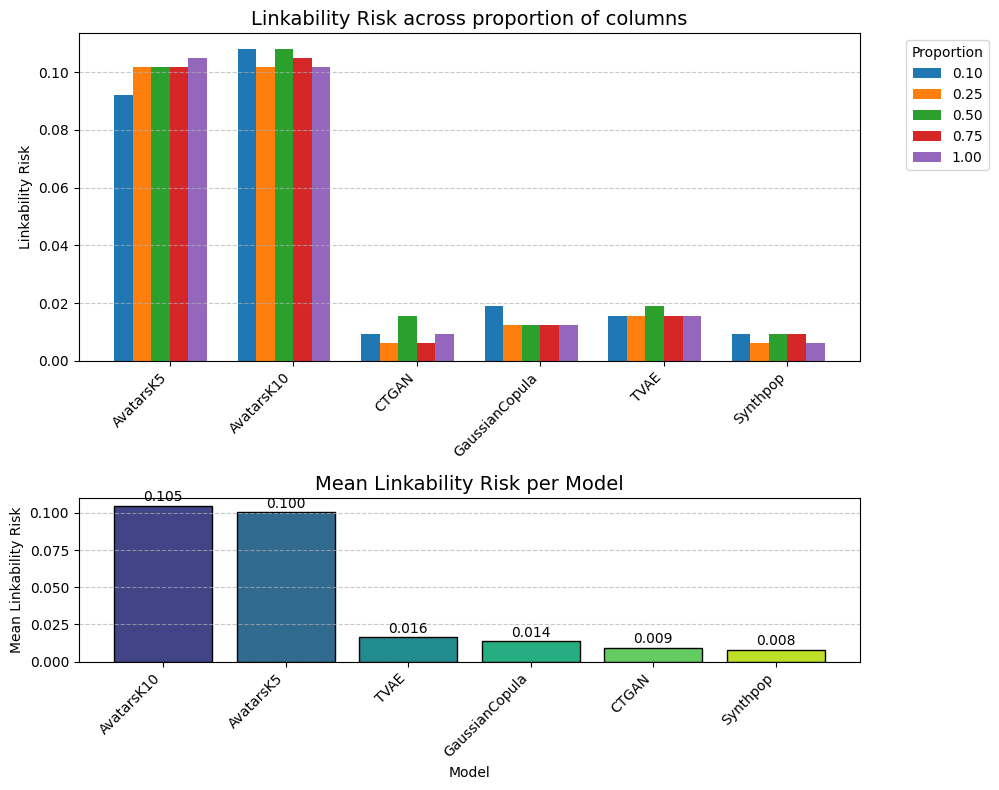

In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Your data ---
results = linkability_res_genes_to_clinical
proportions = [0.1, 0.25, 0.5, 0.75, 1.0]
df = pd.DataFrame(results, index=proportions)

# Compute mean per model for lower plot
means = df.mean().sort_values(ascending=False)

# --- Create subplots ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8), height_ratios=[2, 1])
plt.subplots_adjust(hspace=0.4)

x = np.arange(len(df.columns))  # models on x-axis
width = 0.15                    # width of each bar
# colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(proportions)))

for i, p in enumerate(proportions):
    axes[0].bar(x + i*width - (width*len(proportions)/2), df.loc[p], width,
                label=f"{p:.2f}")

axes[0].set_title("Linkability Risk across proportion of columns", fontsize=14)
axes[0].set_ylabel("Linkability Risk")
axes[0].set_xticks(x)
axes[0].set_xticklabels(df.columns, rotation=45, ha='right')
axes[0].legend(title="Proportion", bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 🎯 2️⃣ Lower plot — mean performance
colors_mean = plt.cm.viridis(np.linspace(0.2, 0.9, len(means)))
bars = axes[1].bar(means.index, means.values, color=colors_mean, edgecolor='black')

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 0.001,
                 f"{height:.3f}", ha='center', va='bottom', fontsize=10)

axes[1].set_title("Mean Linkability Risk per Model", fontsize=14)
axes[1].set_ylabel("Mean Linkability Risk")
axes[1].set_xlabel("Model")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_xticklabels(means.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()
